In [1]:
import pypdf

Número de PDFs:

In [2]:
import os

path_to_data = "./data/raw"

total_pdfs = len([f for f in os.listdir(path_to_data) if f.endswith('.pdf')])
print(f"Total PDFs found: {total_pdfs}")

Total PDFs found: 59


Total pages across all PDFs 22681
PDFs with more than 100 pages:
BOE-120_Codigo_de_Legislacion_Ferroviaria.pdf: 2239 pages
BOE-108_Codigo_de_Derecho_de_la_Navegacion_Maritima_y_Aerea.pdf: 2184 pages
BOE-020_Codigo_de_Trafico_y_Seguridad_Vial.pdf: 2110 pages
BOE-256_Codigo_de_Legislacion_Aeroportuaria.pdf: 1765 pages
BOE-042_Codigo_de_Derecho_Constitucional.pdf: 1325 pages
Manual_práctico_de_Renta_2025._Parte_1..pdf: 1270 pages
BOE-110_Codigo_de_las_Telecomunicaciones.pdf: 1231 pages
BOE-168_Codigo_de_Derecho_Audiovisual.pdf: 1200 pages
BOE-327_Codigo_del_Transporte_de_Mercancias_por_Carretera.pdf: 1193 pages
Manual-de-Reformas-de-Vehiculos-Revision-7-Correcion-2.pdf: 828 pages
Manual_Tiempos_optimos.pdf: 758 pages
BOE-A-2003-23514-consolidado.pdf: 726 pages
Manual_práctico_de_Renta_2025._Parte_2._Deducciones_autonómicas.pdf: 633 pages
BOE-030_Ley_General_Tributaria_y_sus_reglamentos.pdf: 510 pages
BOE-605_Codigo_de_Derecho_de_los_Viajeros.pdf: 471 pages
BOE-607_Codigo_de_Aeronaves_U

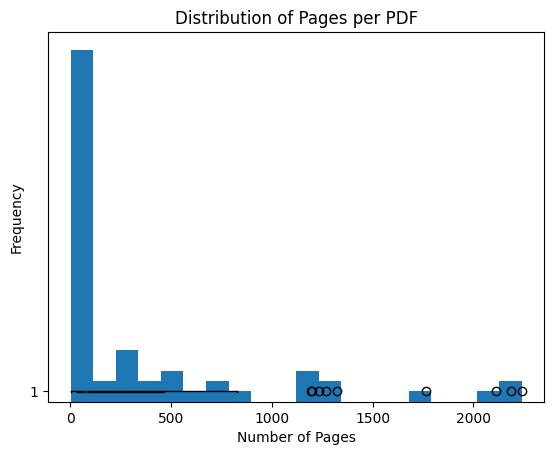

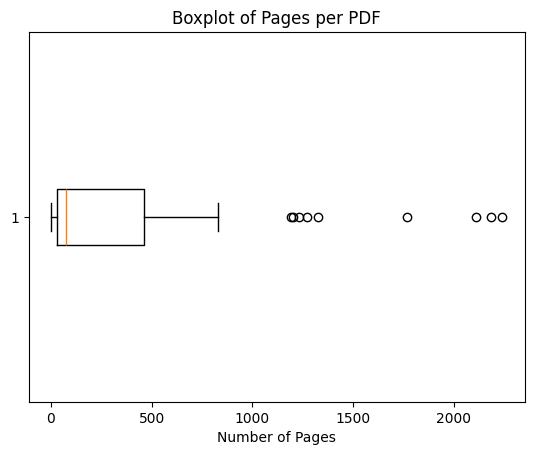

Mean: 384.4237288135593
Median: 75.0
Standard Deviation: 582.2453965552882
Min: 1
Max: 2239


In [ ]:
import matplotlib.pyplot as plt

# distribution of pages per PDF
pages_per_pdf = {}
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with open(pdf_path, 'rb') as f:
                reader = pypdf.PdfReader(f)
                pages_per_pdf[filename] = len(reader.pages)
        except Exception as e:
            print(f"Error reading {filename}: {e}")

print("Total pages across all PDFs", sum(pages_per_pdf.values()))

# PDFs with more than 100 pages ordered by number of pages
long_pdfs = {k: v for k, v in pages_per_pdf.items() if v > 100}
long_pdfs = dict(sorted(long_pdfs.items(), key=lambda item: item[1], reverse=True))
print("PDFs with more than 100 pages:")
for filename, num_pages in long_pdfs.items():
    print(f"{filename}: {num_pages} pages")

# plot distribution
plt.hist(pages_per_pdf.values(), bins=20)
plt.title('Distribution of Pages per PDF')
plt.xlabel('Number of Pages')
plt.ylabel('Frequency')
plt.show()  

# boxplot
plt.boxplot(pages_per_pdf.values(), vert=False)
plt.title('Boxplot of Pages per PDF')
plt.xlabel('Number of Pages')
plt.show()

# describe statistics
import numpy as np
pages_array = np.array(list(pages_per_pdf.values()))
print(f"Mean: {np.mean(pages_array)}")
print(f"Median: {np.median(pages_array)}")
print(f"Standard Deviation: {np.std(pages_array)}")
print(f"Min: {np.min(pages_array)}")
print(f"Max: {np.max(pages_array)}")

Total images across all PDFs 16807
PDFs with more than 10 images:
ANM2026_197.pdf: 6266 images
BOE-120_Codigo_de_Legislacion_Ferroviaria.pdf: 2171 images
Manual_Tiempos_optimos.pdf: 1599 images
Manual_práctico_de_Renta_2025._Parte_1..pdf: 1278 images
BOE-020_Codigo_de_Trafico_y_Seguridad_Vial.pdf: 893 images
Manual-de-Reformas-de-Vehiculos-Revision-7-Correcion-2.pdf: 824 images
Manual_práctico_de_Renta_2025._Parte_2._Deducciones_autonómicas.pdf: 634 images
BOE-A-2003-23514-consolidado.pdf: 620 images
BOE-256_Codigo_de_Legislacion_Aeroportuaria.pdf: 566 images
BOE-108_Codigo_de_Derecho_de_la_Navegacion_Maritima_y_Aerea.pdf: 364 images
Manual_IVA_2025.pdf: 354 images
BOE-110_Codigo_de_las_Telecomunicaciones.pdf: 340 images
BOE-327_Codigo_del_Transporte_de_Mercancias_por_Carretera.pdf: 175 images
BOE-168_Codigo_de_Derecho_Audiovisual.pdf: 145 images
BOE-A-2023-7936.pdf: 108 images
BOE-605_Codigo_de_Derecho_de_los_Viajeros.pdf: 70 images
BOE-A-2022-987.pdf: 68 images
BOE-A-2004-18911-co

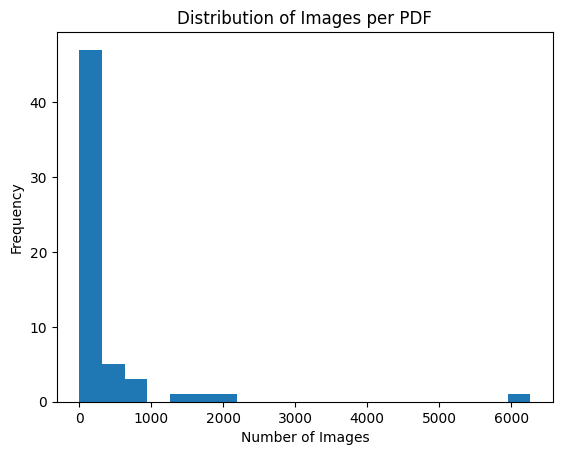

Mean: 284.864406779661
Median: 4.0
Standard Deviation: 887.0062667240286
Min: 0
Max: 6266


In [13]:
# images in PDFs
images_per_pdf = {}
for filename in os.listdir(path_to_data):
    if filename.endswith('.pdf'):
        pdf_path = os.path.join(path_to_data, filename)
        try:
            with open(pdf_path, 'rb') as f:
                reader = pypdf.PdfReader(f)
                num_images = 0
                for page in reader.pages:
                    if '/XObject' in page['/Resources']:
                        xobjects = page['/Resources']['/XObject'].get_object()
                        for obj in xobjects:
                            if xobjects[obj]['/Subtype'] == '/Image':
                                num_images += 1
                images_per_pdf[filename] = num_images
        except Exception as e:
            print(f"Error reading {filename}: {e}")

print("Total images across all PDFs", sum(images_per_pdf.values()))

# PDFs with more than 10 images ordered by number of images
image_rich_pdfs = {k: v for k, v in images_per_pdf.items() if v > 10}
image_rich_pdfs = dict(sorted(image_rich_pdfs.items(), key=lambda item: item[1], reverse=True))
print("PDFs with more than 10 images:")
for filename, num_images in image_rich_pdfs.items():
    print(f"{filename}: {num_images} images")

# plot distribution of images
plt.hist(images_per_pdf.values(), bins=20)
plt.title('Distribution of Images per PDF')
plt.xlabel('Number of Images')
plt.ylabel('Frequency')
plt.show()

# describe statistics of images
images_array = np.array(list(images_per_pdf.values()))
print(f"Mean: {np.mean(images_array)}")
print(f"Median: {np.median(images_array)}")
print(f"Standard Deviation: {np.std(images_array)}")
print(f"Min: {np.min(images_array)}")
print(f"Max: {np.max(images_array)}")